# Model evaluation

This notebook analyzes the development results produced by:

```bash
python -m scripts.run_experiments
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## Load experiment results

The notebook expects `results/development_results.csv`, generated by the experiment runner.

The path resolution below works whether the notebook is launched from the repository root or from the `notebooks/` directory.


In [2]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run the notebook from inside the repository."
    )


PROJECT_ROOT = find_project_root()
RESULTS_PATH = PROJECT_ROOT / "results" / "development_results.csv"

PROJECT_ROOT, RESULTS_PATH


(PosixPath('/home/adrian/Proyectos/gas-sensor-drift-classification'),
 PosixPath('/home/adrian/Proyectos/gas-sensor-drift-classification/results/development_results.csv'))

In [3]:
results = pd.read_csv(RESULTS_PATH)

print(f"Rows: {len(results):,}")
print(f"Models: {results['model'].nunique()}")
print(f"Protocols: {results['protocol'].nunique()}")

results.head()


Rows: 13
Models: 1
Protocols: 2


,model,protocol,split,train_batches,validation_batches,validation_batch,n_train,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
0,logistic_regression,random_stratified,random_fold_1,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.992805,0.993695,0.996198,0.996778,0.982968,0.996255,0.992761,0.991870
1,logistic_regression,random_stratified,random_fold_2,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.993097,0.994180,0.996178,0.998924,0.987952,0.988806,0.994819,0.991903
2,logistic_regression,random_stratified,random_fold_3,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.990723,0.991271,0.992347,0.993562,0.975728,0.998131,0.988601,0.995968
3,logistic_regression,random_stratified,random_fold_4,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.990373,0.990786,0.991083,0.992497,0.982968,0.998131,0.989605,0.987952
4,logistic_regression,random_stratified,random_fold_5,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.983308,0.985451,0.992308,0.993562,0.961353,0.981203,0.983471,0.987952


### Basic checks

These checks help catch malformed output before analysis.


In [4]:
required_columns = {
    "model",
    "protocol",
    "split",
    "macro_f1",
    "accuracy",
}

missing_columns = required_columns - set(results.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

print("Protocols:", sorted(results["protocol"].unique()))
print("Models:", sorted(results["model"].unique()))


Protocols: ['expanding_window', 'random_stratified']
Models: ['logistic_regression']


## Helper functions

Per-class metric columns are detected dynamically rather than assuming a fixed number of classes.

In [5]:
def class_f1_columns(df: pd.DataFrame) -> list[str]:
    columns = [
        column
        for column in df.columns
        if column.startswith("f1_class_")
    ]

    return sorted(
        columns,
        key=lambda column: int(column.rsplit("_", maxsplit=1)[1]),
    )


def protocol_results(
    df: pd.DataFrame,
    protocol: str,
) -> pd.DataFrame:
    return df.loc[df["protocol"] == protocol].copy()


CLASS_F1_COLUMNS = class_f1_columns(results)
CLASS_F1_COLUMNS


['f1_class_1',
 'f1_class_2',
 'f1_class_3',
 'f1_class_4',
 'f1_class_5',
 'f1_class_6']

## Random stratified evaluation

Random stratified cross-validation is used as a conventional IID-like reference. Because acquisition batches are mixed across folds, it should not be interpreted as a deployment-like estimate under temporal distribution shift.


In [6]:
random_results = protocol_results(
    results,
    "random_stratified",
)

random_results[
    ["model", "split", "macro_f1", "accuracy"]
].sort_values(["model", "split"])


,model,split,macro_f1,accuracy
0,logistic_regression,random_fold_1,0.992805,0.993695
1,logistic_regression,random_fold_2,0.993097,0.994180
2,logistic_regression,random_fold_3,0.990723,0.991271
3,logistic_regression,random_fold_4,0.990373,0.990786
4,logistic_regression,random_fold_5,0.983308,0.985451


In [7]:
random_summary = (
    random_results
    .groupby("model")[["macro_f1", "accuracy"]]
    .agg(["mean", "std"])
)

random_summary


macro_f1            accuracy          
                         mean       std      mean       std
model                                                      
logistic_regression  0.990061  0.003965  0.991077  0.003474

### Mean per-class F1 under random stratified CV

This checks whether strong aggregate performance hides any systematically weaker class.


In [8]:
random_class_summary = (
    random_results
    .groupby("model")[CLASS_F1_COLUMNS]
    .mean()
)

random_class_summary


,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
model,,,,,,
logistic_regression,0.993623,0.995065,0.978194,0.992505,0.989851,0.991129


## Expanding-window temporal evaluation

For each validation batch, the model is trained only on earlier batches. Results are kept per batch rather than collapsed into a single mean because validation sets differ substantially in size and class composition.


In [9]:
temporal_results = protocol_results(
    results,
    "expanding_window",
)

temporal_columns = [
    "model",
    "validation_batch",
    "n_validation",
    "macro_f1",
    "accuracy",
    *CLASS_F1_COLUMNS,
]

temporal_results[
    temporal_columns
].sort_values(["model", "validation_batch"])


,model,validation_batch,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,logistic_regression,2.0,1244,0.670920,0.819132,0.599620,0.956790,0.811429,0.000000,0.943396,0.714286
6,logistic_regression,3.0,1586,0.852541,0.859395,0.615108,0.991820,0.986239,0.691843,0.977695,NaN
7,logistic_regression,4.0,161,0.771161,0.751553,0.690909,0.951220,1.000000,0.769231,0.444444,NaN
8,logistic_regression,5.0,197,0.980111,0.979695,0.982456,1.000000,0.974359,0.967742,0.976000,NaN
9,logistic_regression,6.0,2300,0.655378,0.773913,0.946579,0.992098,0.914027,0.115308,0.964256,0.000000
10,logistic_regression,7.0,3613,0.826398,0.833379,0.985573,0.745209,0.809961,0.490872,0.969931,0.956841
11,logistic_regression,8.0,294,0.883729,0.914966,0.909091,0.947368,0.771429,0.942857,0.958904,0.772727
12,logistic_regression,9.0,470,0.756134,0.770213,0.983607,1.000000,0.985222,0.581673,0.966887,0.019417


### Temporal macro-F1 by batch

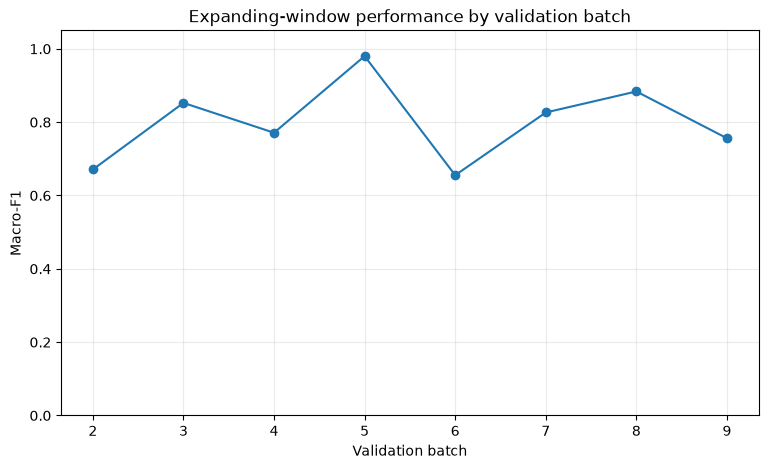

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for model_name, model_results in temporal_results.groupby("model"):
    ordered = model_results.sort_values("validation_batch")

    ax.plot(
        ordered["validation_batch"],
        ordered["macro_f1"],
        marker="o",
        label=model_name,
    )

ax.set_xlabel("Validation batch")
ax.set_ylabel("Macro-F1")
ax.set_title("Expanding-window performance by validation batch")
ax.set_ylim(0.0, 1.05)
ax.grid(alpha=0.25)

if temporal_results["model"].nunique() > 1:
    ax.legend()

plt.show()


### Accuracy vs macro-F1

A large gap can indicate uneven performance across classes, especially in batches with strongly imbalanced class distributions.


In [11]:
metric_gap = temporal_results[
    ["model", "validation_batch", "macro_f1", "accuracy"]
].copy()

metric_gap["accuracy_minus_macro_f1"] = (
    metric_gap["accuracy"] - metric_gap["macro_f1"]
)

metric_gap.sort_values(
    ["model", "accuracy_minus_macro_f1"],
    ascending=[True, False],
)


,model,validation_batch,macro_f1,accuracy,accuracy_minus_macro_f1
5,logistic_regression,2.0,0.670920,0.819132,0.148212
9,logistic_regression,6.0,0.655378,0.773913,0.118535
11,logistic_regression,8.0,0.883729,0.914966,0.031237
12,logistic_regression,9.0,0.756134,0.770213,0.014078
10,logistic_regression,7.0,0.826398,0.833379,0.006982
6,logistic_regression,3.0,0.852541,0.859395,0.006854
8,logistic_regression,5.0,0.980111,0.979695,-0.000416
7,logistic_regression,4.0,0.771161,0.751553,-0.019608


### Per-class temporal performance

Absent classes remain `NaN`, which is intentionally different from F1 = 0.


In [12]:
temporal_class_results = temporal_results[
    [
        "model",
        "validation_batch",
        *CLASS_F1_COLUMNS,
    ]
].sort_values(["model", "validation_batch"])

temporal_class_results


,model,validation_batch,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,logistic_regression,2.0,0.599620,0.956790,0.811429,0.000000,0.943396,0.714286
6,logistic_regression,3.0,0.615108,0.991820,0.986239,0.691843,0.977695,NaN
7,logistic_regression,4.0,0.690909,0.951220,1.000000,0.769231,0.444444,NaN
8,logistic_regression,5.0,0.982456,1.000000,0.974359,0.967742,0.976000,NaN
9,logistic_regression,6.0,0.946579,0.992098,0.914027,0.115308,0.964256,0.000000
10,logistic_regression,7.0,0.985573,0.745209,0.809961,0.490872,0.969931,0.956841
11,logistic_regression,8.0,0.909091,0.947368,0.771429,0.942857,0.958904,0.772727
12,logistic_regression,9.0,0.983607,1.000000,0.985222,0.581673,0.966887,0.019417


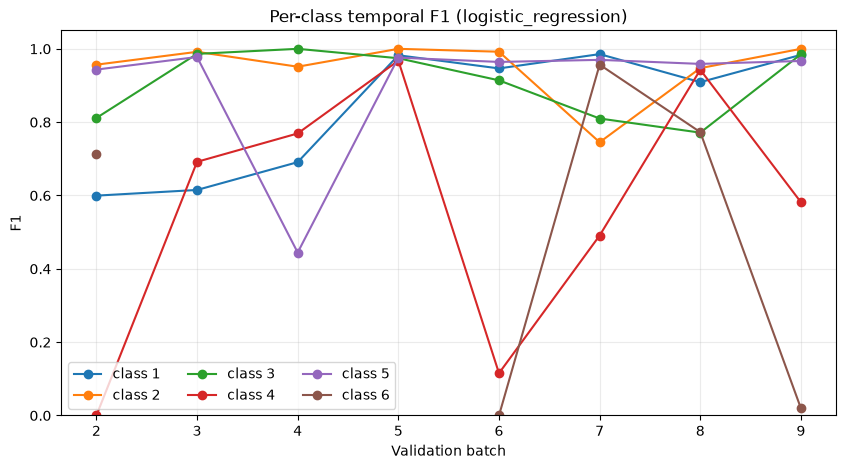

In [17]:
for model_name, model_results in temporal_results.groupby("model"):
    ordered = model_results.sort_values("validation_batch")

    fig, ax = plt.subplots(figsize=(10, 5))

    for column in CLASS_F1_COLUMNS:
        class_label = column.rsplit("_", maxsplit=1)[1]

        ax.plot(
            ordered["validation_batch"],
            ordered[column],
            marker="o",
            label=f"class {class_label}",
        )

    ax.set_xlabel("Validation batch")
    ax.set_ylabel("F1")
    ax.set_title(f"Per-class temporal F1 ({model_name})")
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(ncol=3)

    plt.show()


## Random vs temporal evaluation

This comparison is descriptive. Random-CV folds are repetitions of the same protocol, while temporal validation batches differ in size and class composition. Temporal performance is therefore preserved batch by batch.


In [16]:
random_means = (
    random_results
    .groupby("model", as_index=False)["macro_f1"]
    .mean()
    .rename(columns={"macro_f1": "random_cv_macro_f1_mean"})
)

temporal_ranges = (
    temporal_results
    .groupby("model")["macro_f1"]
    .agg(
        temporal_macro_f1_min="min",
        temporal_macro_f1_max="max",
    )
    .reset_index()
)

comparison = random_means.merge(
    temporal_ranges,
    on="model",
    how="outer",
)

comparison


,model,random_cv_macro_f1_mean,temporal_macro_f1_min,temporal_macro_f1_max
0,logistic_regression,0.990061,0.655378,0.980111
